# 03. GAT

This notebook trains a `GAT` node-classification model on the sampled wash-trading graph.

Included by default:

- stratified train/val/test split
- train-time early stopping
- threshold tuning on validation set
- compact train/test metric summary
- test confusion matrix with TP/FP/TN/FN counts

Default restriction:

- `ADD_GRAPH_STATS = False`
- node features are used without explicit graph-stat columns


In [10]:
from pathlib import Path
import sys

import pandas as pd

module_dir_candidates = [Path.cwd(), Path.cwd() / "graph_models", Path.cwd().parent / "graph_models"]
module_dir = next(path for path in module_dir_candidates if (path / "graph_model_utils.py").exists())
sys.path.append(str(module_dir))

from graph_model_utils import (
    build_graph_dataset,
    find_best_threshold,
    get_model,
    predict_probabilities,
    set_seed,
    train_model,
)


In [11]:
MODEL_NAME = "gat"
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
HIDDEN_DIM = 32
DROPOUT = 0.3
LEARNING_RATE = 0.00075
WEIGHT_DECAY = 1e-4
EPOCHS = 120
PATIENCE = 18
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [12]:
data = build_graph_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame([data["graph_summary"]]))
display(data["split_df"])
print("Device:", data["device"])
print("Number of input features:", len(data["feature_cols"]))


,num_nodes,num_edges,num_features,positive_nodes,negative_nodes,has_self_loops_after_build
0,10000,283909,8,1126,8874,True


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Device: cpu
Number of input features: 8


In [13]:
model = get_model(
    model_name=MODEL_NAME,
    in_dim=data["features"].shape[1],
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", parameter_count)


GATModel(
  (gat1): GATConv(
    (fc): Linear(in_features=8, out_features=128, bias=False)
    (feat_drop): Dropout(p=0.3, inplace=False)
    (attn_drop): Dropout(p=0.3, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (gat2): GATConv(
    (fc): Linear(in_features=128, out_features=32, bias=False)
    (feat_drop): Dropout(p=0.3, inplace=False)
    (attn_drop): Dropout(p=0.3, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)
Trainable parameters: 5666


In [14]:
best_model, history_df = train_model(
    model=model,
    data=data,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

print("Training completed!")


Training completed!


In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

train_true, train_prob = predict_probabilities(best_model, data, "train_mask")
val_true, val_prob = predict_probabilities(best_model, data, "val_mask")
test_true, test_prob = predict_probabilities(best_model, data, "test_mask")

best_threshold = find_best_threshold(val_true, val_prob, objective=THRESHOLD_OBJECTIVE)

train_pred = (train_prob >= best_threshold).astype(int)
train_metrics = {
    "ROC-AUC": roc_auc_score(train_true, train_prob),
    "F1": f1_score(train_true, train_pred),
    "Precision": precision_score(train_true, train_pred),
    "Recall": recall_score(train_true, train_pred),
}

test_pred = (test_prob >= best_threshold).astype(int)
test_metrics = {
    "ROC-AUC": roc_auc_score(test_true, test_prob),
    "F1": f1_score(test_true, test_pred),
    "Precision": precision_score(test_true, test_pred),
    "Recall": recall_score(test_true, test_pred),
}

print("=" * 50)
print("TRAIN SET METRICS")
print("=" * 50)
for metric, value in train_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n" + "=" * 50)
print("TEST SET METRICS (Threshold: {:.4f})".format(best_threshold))
print("=" * 50)
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")


TRAIN SET METRICS
ROC-AUC: 0.6990
F1: 0.4515
Precision: 0.6043
Recall: 0.3604

TEST SET METRICS (Threshold: 0.5000)
ROC-AUC: 0.6856
F1: 0.4840
Precision: 0.6071
Recall: 0.4024


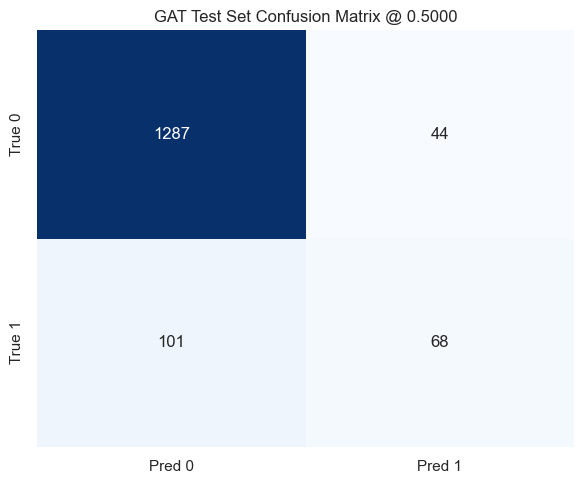


Confusion Matrix Values:
True Negatives: 1287
False Positives: 44
False Negatives: 101
True Positives: 68


In [16]:
from sklearn.metrics import confusion_matrix
#djed
sns.set_theme(style="whitegrid")
cm = confusion_matrix(test_true, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
)
plt.title(f"{MODEL_NAME.upper()} Test Set Confusion Matrix @ {best_threshold:.4f}")
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Values:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")


In [17]:
print("Evaluation complete: Train metrics, Test metrics, and Confusion Matrix shown")


Evaluation complete: Train metrics, Test metrics, and Confusion Matrix shown


In [18]:
test_node_rows = data["nodes_df"].loc[data["test_mask"].detach().cpu().numpy()].copy()
test_node_rows["predicted_probability"] = test_prob
test_node_rows["predicted_label"] = (test_prob >= best_threshold).astype(int)

suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
2046,258361,1,0.887143,1,2,0
1773,230116,1,0.784370,1,1,0
2209,276703,1,0.777584,1,1,0
1539,204115,1,0.771560,1,1,1
1520,203021,1,0.769536,1,1,0
1598,210566,1,0.723702,1,1,0
2492,310231,1,0.713593,1,1,1
1982,253484,1,0.709391,1,1,1
2643,328725,1,0.675225,1,2,1
6045,766063,1,0.660420,1,2,1


## Notes

Keep the reported `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing models.
The threshold comes from validation data and is reused on the test split.
